In [1]:
pip install --user mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import mysql.connector

print("MySQL connector is working!")

MySQL connector is working!


In [4]:
import mysql.connector

In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv','order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='divya',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/kk/Desktop/Datasets/Ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect(
    host='localhost',
    user='root',
    password='divya',
    database='ecommerce'
)
cur=db.cursor()

#List all unique cities where customers are located

In [4]:
query=""" select distinct customer_city from customers """
cur.execute(query)
data=cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

#2. Count the number of orders placed in 2017.

In [12]:
query=""" select count(order_id) from orders where year(order_purchase_timestamp)=2017"""
cur.execute(query)
data=cur.fetchall()
data
"total orders placed in 2017 are",data[0][0]

('total orders placed in 2017 are', 135303)

#3. Find the total sales per category.

In [13]:
query=""" select products.product_category category,round(sum(payments.payment_value)) from products join order_items on products.product_id=order_items.product_id join payments on payments.order_id=order_items.order_id group by category"""
cur.execute(query)
data=cur.fetchall()
data

[('perfumery', 1013477.0),
 ('Furniture Decoration', 2860353.0),
 ('telephony', 973764.0),
 ('bed table bath', 3425107.0),
 ('automotive', 1704589.0),
 ('computer accessories', 3170661.0),
 ('housewares', 2189516.0),
 ('babies', 1079691.0),
 ('toys', 1238075.0),
 ('Furniture office', 1293653.0),
 ('Cool Stuff', 1559396.0),
 ('HEALTH BEAUTY', 3314746.0),
 ('pet Shop', 622538.0),
 ('General Interest Books', 129390.0),
 ('stationary store', 634880.0),
 ('Watches present', 2858433.0),
 ('PCs', 558243.0),
 ('climatization', 182341.0),
 ('Construction Tools Construction', 482951.0),
 ('sport leisure', 2784255.0),
 ('Bags Accessories', 374303.0),
 ('electronics', 519714.0),
 ('Casa Construcao', 273291.0),
 ('Games consoles', 390961.0),
 ('Fashion Bags and Accessories', 436317.0),
 ('home appliances', 191065.0),
 ('Garden tools', 1676562.0),
 ('Agro Industria e Comercio', 237461.0),
 (None, 505603.0),
 ('audio', 120649.0),
 ('technical books', 49831.0),
 ('Construction Tools Garden', 84789.0),

In [18]:
df=pd.DataFrame(data,columns=["category","sales"])
df

,category,sales
0,perfumery,1013477.0
1,Furniture Decoration,2860353.0
2,telephony,973764.0
3,bed table bath,3425107.0
4,automotive,1704589.0
...,...,...
69,cds music dvds,2399.0
70,La Cuisine,5827.0
71,Fashion Children's Clothing,1571.0
72,PC Gamer,4349.0


4. Calculate the percentage of orders that were paid in installments.


In [19]:
query = """ select ((sum(case when payment_installments >= 1 then 1
else 0 end))/count(*))*100 from payments
"""

cur.execute(query)

data = cur.fetchall()

"the percentage of orders that were paid in installments is", data[0][0]

('the percentage of orders that were paid in installments is',
 Decimal('99.9981'))


Count the number of customers from each state.

In [20]:
query = """ select customer_state ,count(customer_id)
from customers group by customer_state
"""
cur.execute(query)

data = cur.fetchall()
data

[('SP', 125238),
 ('SC', 10911),
 ('MG', 34905),
 ('PR', 15135),
 ('RJ', 38556),
 ('RS', 16398),
 ('PA', 2925),
 ('GO', 6060),
 ('ES', 6099),
 ('BA', 10140),
 ('MA', 2241),
 ('MS', 2145),
 ('CE', 4008),
 ('DF', 6420),
 ('RN', 1455),
 ('PE', 4956),
 ('MT', 2721),
 ('AM', 444),
 ('AP', 204),
 ('AL', 1239),
 ('RO', 759),
 ('PB', 1608),
 ('TO', 840),
 ('PI', 1485),
 ('AC', 243),
 ('SE', 1050),
 ('RR', 138)]

In [22]:
df = pd.DataFrame(data, columns = ["state", "customer_count" ])
df

,state,customer_count
0,SP,125238
1,SC,10911
2,MG,34905
3,PR,15135
4,RJ,38556
5,RS,16398
6,PA,2925
7,GO,6060
8,ES,6099
9,BA,10140


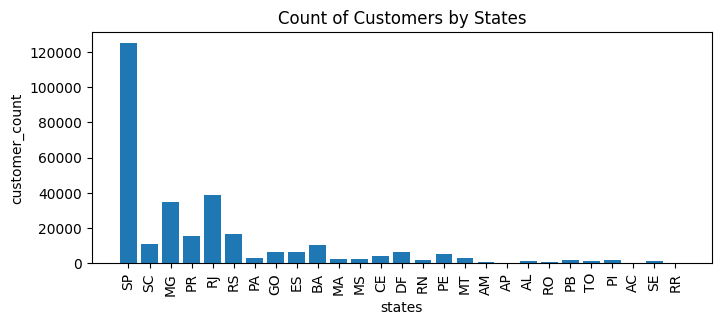

In [23]:
plt.figure(figsize = (8,3))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation = 90)
plt.xlabel("states")
plt.ylabel("customer_count")
plt.title("Count of Customers by States")
plt.show()

Calculate the number of orders per month in 2018.

In [25]:

query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
data

[('July', 18876),
 ('August', 19536),
 ('February', 20184),
 ('June', 18501),
 ('March', 21633),
 ('January', 21807),
 ('May', 20619),
 ('April', 20817),
 ('September', 48),
 ('October', 12)]

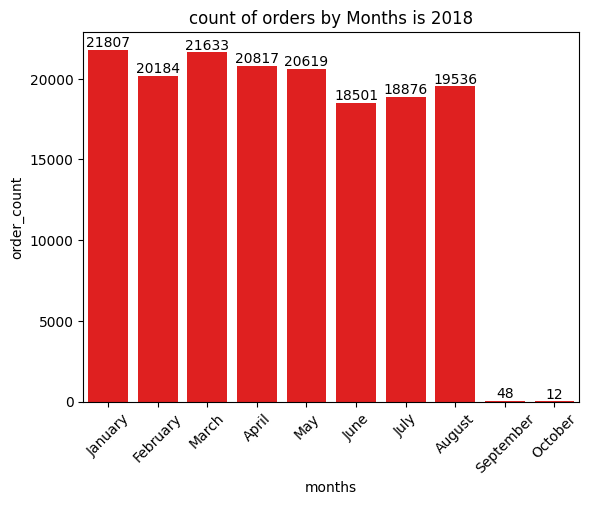

In [29]:
df=pd.DataFrame(data,columns=["months","order_count"])
m=["January","February","March","April","May","June","July","August","September","October"]
ax=sns.barplot(x=df["months"],y=df["order_count"],data=df,order=m,color="red")
ax.bar_label(ax.containers[0])
plt.xticks(rotation = 45)
plt.title("count of orders by Months is 2018")
plt.show()



Find the average number of products per order, grouped by customer city.

In [30]:
query = """with count_per_order as 
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer city", "average products/order"])
df.head(10)

,customer city,average products/order
0,padre carvalho,21.00
1,celso ramos,19.50
2,datas,18.00
3,candido godoi,18.00
4,matias olimpio,15.00
5,cidelandia,12.00
6,curralinho,12.00
7,picarra,12.00
8,morro de sao paulo,12.00
9,teixeira soares,12.00
